# RDF N-Triples Analysis Notebook using rdflib


In [1]:
name = "quote"

# =========================

# 1. Setup

# =========================


In [2]:
from rdflib import Graph, URIRef, Literal, Namespace
from rdflib.namespace import RDF, RDFS, SKOS, XSD
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

## Helper Functions


In [3]:
def parse_file_safe(graph, path):
    encodings = ["utf-8", "latin-1", "cp1252"]

    for enc in encodings:
        try:
            with open(path, "r", encoding=enc) as f:
                graph.parse(f, format="nt")
            print(f"Loaded {path} with {enc}")
            return
        except UnicodeDecodeError:
            continue

    print(f"Failed to parse {path}")

# =========================

# 2. Load N-Triples Files

# =========================


In [4]:
import os

data_dir = "data"
g = Graph()


for file in os.listdir(data_dir):
    if name in file and file.endswith(".ntriples"):
        path = os.path.join(data_dir, file)
        print(f"Loading {path}")
        parse_file_safe(g, path)

print(f"Total triples loaded: {len(g)}")

Loading data\OpenPermID-bulk-quote.ntriples
Loaded data\OpenPermID-bulk-quote.ntriples with utf-8
Total triples loaded: 360


# =========================

# 3. Inspect Basic Structure

# =========================


In [5]:
# Print first 10 triples
for i, (s, p, o) in enumerate(g):
    if i >= 10:
        break
    print(s, p, o)

https://permid.org/quote-0046 https://permid.org/ontology/financial/lotSize 1
https://permid.org/quote-0059 http://www.w3.org/1999/02/22-rdf-syntax-ns#type https://permid.org/ontology/financial/SecondaryQuote
https://permid.org/quote-0016 http://www.w3.org/2000/01/rdf-schema#label Quote-0016
https://permid.org/quote-0008 https://permid.org/ontology/financial/lotSize 1000
https://permid.org/quote-0026 https://permid.org/ontology/financial/quotedOrganization https://permid.org/org-0026
https://permid.org/quote-0026 https://permid.org/ontology/financial/listedOn SSE
https://permid.org/quote-0036 https://permid.org/ontology/financial/quotedOrganization https://permid.org/org-0006
https://permid.org/quote-0021 https://permid.org/ontology/financial/lotSize 1
https://permid.org/quote-0014 https://permid.org/ontology/financial/lotSize 10
https://permid.org/quote-0054 https://permid.org/ontology/financial/lotSize 100


# =========================

# 4. Explore Unique Elements

# =========================


In [6]:
subjects = set()
predicates = set()
uri_predicates = set()
literal_predicates = set()
objects = set()
both = set()
count = 0
for s, p, o in g:
    subjects.add(s)
    predicates.add(p)
    objects.add(o)
    both.add(s)
    both.add(o)
    if isinstance(o, Literal):
        literal_predicates.add(p)
    else:
        uri_predicates.add(p)
    count += 1


print("Total Size:", count)
print("Unique subjects:", len(subjects))
print("Unique predicates:", len(predicates))
print("Unique objects:", len(objects))
print("Unique Both:", len(both))

Total Size: 360
Unique subjects: 60
Unique predicates: 6
Unique objects: 127
Unique Both: 187


In [7]:
print(uri_predicates)


{rdflib.term.URIRef('https://permid.org/ontology/financial/quoteCurrency'), rdflib.term.URIRef('http://www.w3.org/1999/02/22-rdf-syntax-ns#type'), rdflib.term.URIRef('https://permid.org/ontology/financial/quotedOrganization')}


In [8]:
print(literal_predicates)

{rdflib.term.URIRef('https://permid.org/ontology/financial/listedOn'), rdflib.term.URIRef('https://permid.org/ontology/financial/lotSize'), rdflib.term.URIRef('http://www.w3.org/2000/01/rdf-schema#label')}


Conclusion: Majority of subjects are not objects


# =========================

# 5. Convert to DataFrame

# =========================


In [9]:
data = [(str(s), str(p), str(o)) for s, p, o in g]
df = pd.DataFrame(data, columns=["subject", "predicate", "object"])

df.head()

# Predicate frequency
predicate_counts = df["predicate"].value_counts()
predicate_counts.head(10)

predicate
https://permid.org/ontology/financial/lotSize               60
http://www.w3.org/1999/02/22-rdf-syntax-ns#type             60
http://www.w3.org/2000/01/rdf-schema#label                  60
https://permid.org/ontology/financial/quotedOrganization    60
https://permid.org/ontology/financial/listedOn              60
https://permid.org/ontology/financial/quoteCurrency         60
Name: count, dtype: int64

# =========================

# 6. Namespace Handling

# =========================


In [10]:
EX = Namespace("http://permid.org/")

# Bind namespace (useful for serialization)
g.bind("ex", EX)

# =========================

# 7. Filtering Triples

# =========================


In [11]:
# Example: get all labels
labels = []
for s, p, o in g.triples((None, RDFS.label, None)):
    labels.append((s, o))

print("Sample labels:")
print(labels[:10])

Sample labels:
[(rdflib.term.URIRef('https://permid.org/quote-0001'), rdflib.term.Literal('Quote-0001', lang='en')), (rdflib.term.URIRef('https://permid.org/quote-0002'), rdflib.term.Literal('Quote-0002', lang='en')), (rdflib.term.URIRef('https://permid.org/quote-0003'), rdflib.term.Literal('Quote-0003', lang='en')), (rdflib.term.URIRef('https://permid.org/quote-0004'), rdflib.term.Literal('Quote-0004', lang='en')), (rdflib.term.URIRef('https://permid.org/quote-0005'), rdflib.term.Literal('Quote-0005', lang='en')), (rdflib.term.URIRef('https://permid.org/quote-0006'), rdflib.term.Literal('Quote-0006', lang='en')), (rdflib.term.URIRef('https://permid.org/quote-0007'), rdflib.term.Literal('Quote-0007', lang='en')), (rdflib.term.URIRef('https://permid.org/quote-0008'), rdflib.term.Literal('Quote-0008', lang='en')), (rdflib.term.URIRef('https://permid.org/quote-0009'), rdflib.term.Literal('Quote-0009', lang='en')), (rdflib.term.URIRef('https://permid.org/quote-0010'), rdflib.term.Literal('

# =========================

# 8. SPARQL Queries

# =========================


In [12]:
query = """
SELECT ?s ?label
WHERE {
    ?s <http://www.w3.org/2000/01/rdf-schema#label> ?label .
}
LIMIT 10
"""

for row in g.query(query):
    print(row)

# More complex query: hierarchical relations
query_hierarchy = """
SELECT ?child ?parent
WHERE {
    ?child <http://www.w3.org/2004/02/skos/core#broader> ?parent .
}
LIMIT 10
"""

for row in g.query(query_hierarchy):
    print(row)

(rdflib.term.URIRef('https://permid.org/quote-0001'), rdflib.term.Literal('Quote-0001', lang='en'))
(rdflib.term.URIRef('https://permid.org/quote-0002'), rdflib.term.Literal('Quote-0002', lang='en'))
(rdflib.term.URIRef('https://permid.org/quote-0003'), rdflib.term.Literal('Quote-0003', lang='en'))
(rdflib.term.URIRef('https://permid.org/quote-0004'), rdflib.term.Literal('Quote-0004', lang='en'))
(rdflib.term.URIRef('https://permid.org/quote-0005'), rdflib.term.Literal('Quote-0005', lang='en'))
(rdflib.term.URIRef('https://permid.org/quote-0006'), rdflib.term.Literal('Quote-0006', lang='en'))
(rdflib.term.URIRef('https://permid.org/quote-0007'), rdflib.term.Literal('Quote-0007', lang='en'))
(rdflib.term.URIRef('https://permid.org/quote-0008'), rdflib.term.Literal('Quote-0008', lang='en'))
(rdflib.term.URIRef('https://permid.org/quote-0009'), rdflib.term.Literal('Quote-0009', lang='en'))
(rdflib.term.URIRef('https://permid.org/quote-0010'), rdflib.term.Literal('Quote-0010', lang='en'))


# =========================

# 9. Working with Literals

# =========================


In [13]:
for s, p, o in g:
    if isinstance(o, Literal):
        print("Value:", o)
        print("Datatype:", o.datatype)
        print("Python value:", o.toPython())
        print("_---------------------_")

Value: 1
Datatype: None
Python value: 1
_---------------------_
Value: Quote-0016
Datatype: None
Python value: Quote-0016
_---------------------_
Value: 1000
Datatype: None
Python value: 1000
_---------------------_
Value: SSE
Datatype: None
Python value: SSE
_---------------------_
Value: 1
Datatype: None
Python value: 1
_---------------------_
Value: 10
Datatype: None
Python value: 10
_---------------------_
Value: 100
Datatype: None
Python value: 100
_---------------------_
Value: TSE
Datatype: None
Python value: TSE
_---------------------_
Value: Quote-0012
Datatype: None
Python value: Quote-0012
_---------------------_
Value: Quote-0050
Datatype: None
Python value: Quote-0050
_---------------------_
Value: Quote-0006
Datatype: None
Python value: Quote-0006
_---------------------_
Value: 10
Datatype: None
Python value: 10
_---------------------_
Value: Quote-0042
Datatype: None
Python value: Quote-0042
_---------------------_
Value: Quote-0035
Datatype: None
Python value: Quote-003

# =========================

# 10. Graph Navigation

# =========================


In [14]:
# Pick one subject
sample_subject = next(iter(subjects))

print("\nAll triples for one subject:")
for p, o in g.predicate_objects(subject=sample_subject):
    print(p, o)


All triples for one subject:
http://www.w3.org/1999/02/22-rdf-syntax-ns#type https://permid.org/ontology/financial/Delisted
http://www.w3.org/2000/01/rdf-schema#label Quote-0033
https://permid.org/ontology/financial/listedOn LSE
https://permid.org/ontology/financial/quoteCurrency https://permid.org/1-DKK
https://permid.org/ontology/financial/quotedOrganization https://permid.org/org-0003
https://permid.org/ontology/financial/lotSize 10


# =========================

# 11. Build NetworkX Graph

# =========================


NetworkX nodes: 113
NetworkX edges: 180


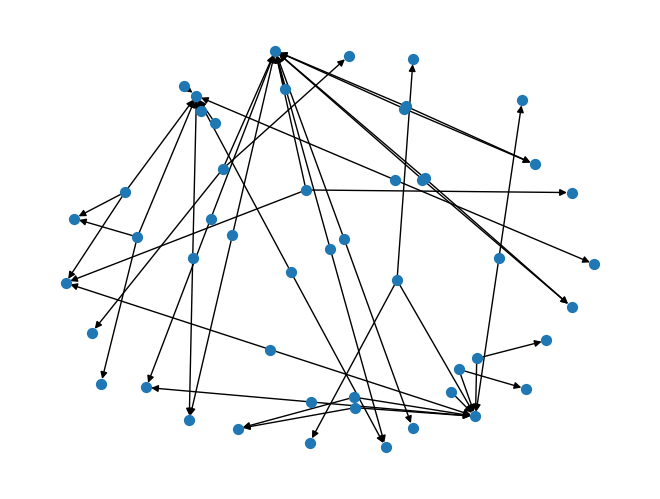

In [15]:
G_nx = nx.DiGraph()

for s, p, o in g:
    if isinstance(o, URIRef):
        G_nx.add_edge(str(s), str(o), label=str(p))

print("NetworkX nodes:", G_nx.number_of_nodes())
print("NetworkX edges:", G_nx.number_of_edges())

# Visualize small subgraph
sub_nodes = list(G_nx.nodes())[:50]
subgraph = G_nx.subgraph(sub_nodes)

plt.figure()
pos = nx.spring_layout(subgraph)
nx.draw(subgraph, pos, node_size=50, with_labels=False)
plt.show()

# =========================

# 12. Serialization

# =========================


In [16]:
# Save graph in different formats
g.serialize("output.ttl", format="turtle")
g.serialize("output.rdf", format="xml")

<Graph identifier=N7527cd03646d404093c4d50f9225fd38 (<class 'rdflib.graph.Graph'>)>

# =========================

# 13. Advanced: Reasoning (basic)

# =========================


In [17]:
# Example: find all broader chains manually


def get_broader_chain(graph, node, depth=3):
    chain = []
    current = node
    for _ in range(depth):
        parent = list(graph.objects(current, SKOS.broader))
        if not parent:
            break
        current = parent[0]
        chain.append(current)
    return chain


sample = next(iter(subjects))
print("\nBroader chain:", get_broader_chain(g, sample))


Broader chain: []


# =========================

# 14. Statistics & Insights

# =========================



Top predicates:
predicate
https://permid.org/ontology/financial/lotSize               60
http://www.w3.org/1999/02/22-rdf-syntax-ns#type             60
http://www.w3.org/2000/01/rdf-schema#label                  60
https://permid.org/ontology/financial/quotedOrganization    60
https://permid.org/ontology/financial/listedOn              60
https://permid.org/ontology/financial/quoteCurrency         60
Name: count, dtype: int64


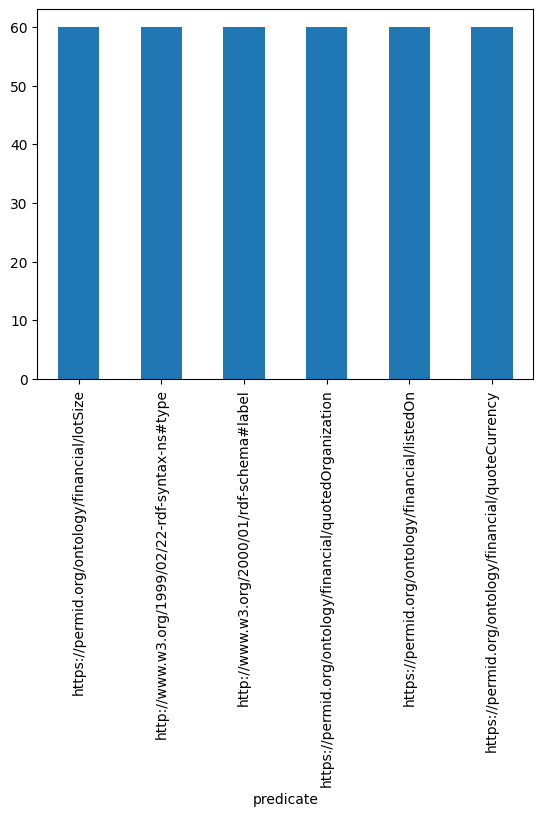

In [18]:
print("\nTop predicates:")
print(predicate_counts.head(30))

# Distribution plot
plt.figure()
predicate_counts.plot(kind="bar")
plt.show()

# =========================

# END

# =========================
